# 02 — Customer Churn modular training pipeline

**Training dataset:** `archive/Customer-Churn-Records.csv`  
**External test:** `archive/Synthetic-Customer-Churn-Test.csv`  
**Target:** `Exited`

Notebook này điều phối pipeline train/validation/external-test sau khi ablation loại 8 engineered features có importance thấp. Validation chỉ dùng cho tuning và model selection; bảng tổng kết cuối cùng lấy từ independent Synthetic test. Toàn bộ feature engineering, preprocessing, model, tuning, evaluation và plotting nằm trong package `pipeline/`.


In [1]:
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


# Step 0 — Config và imports

Config tập trung tại `pipeline/config.py`; thay split, threshold hoặc tuning budget tại một nơi.

In [2]:
import warnings

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

from pipeline.config import DEFAULT_CONFIG
from pipeline.data import load_and_split_data
from pipeline.evaluation import (
    build_validation_results,
    evaluate_external_models,
    select_tuned_model,
)
from pipeline.features import audit_risk_rules, build_feature_bundle
from pipeline.preprocessing import fit_preprocessors
from pipeline.training import train_baseline_models
from pipeline.tuning import tune_models
from pipeline.visualization import (
    plot_external_confusion_matrices,
    plot_validation_comparison,
    set_plot_style,
)

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', lambda value: f'{value:,.4f}')
set_plot_style()

config = DEFAULT_CONFIG
config

PipelineConfig(train_data_path=PosixPath('/Users/minh/churn-rate/archive/Customer-Churn-Records.csv'), external_test_path=PosixPath('/Users/minh/churn-rate/archive/Synthetic-Customer-Churn-Test.csv'), target='Exited', excluded_columns=('RowNumber', 'CustomerId', 'Surname', 'Complain'), dropped_engineered_features=('VeryLowCreditInactive', 'LowCreditShortTenureHasCard', 'ShortTenureUnder5', 'VeryLowCreditScore', 'LowCreditScore425', 'InactiveWithMultipleProducts', 'ZeroBalance', 'CardButInactive'), validation_size=0.15, random_state=42, age_bins=5, operating_threshold=0.4, cv_tie_tolerance=0.002, tuning_iterations=18, cv_splits=5)

# Step 1 — Load, schema check và stratified split 85/15

Logic: `pipeline/data.py`. `CustomerId`, `RowNumber`, `Surname`, `Complain` và target bị loại trước khi split.

In [3]:
data = load_and_split_data(config)

display(data.split_summary.style.format({
    'Rows': '{:,}',
    'Churn rate': '{:.2%}',
}))
print(f'Raw model columns ({len(data.model_columns)}): {data.model_columns}')
print(f'Excluded from model: {[*config.excluded_columns, config.target]}')
print(f'Exact source/external feature-row overlap: {data.external_overlap}')

,Split,Source,Rows,Churn rate,Target use
0,Train,Customer-Churn-Records.csv,"8,500",20.38%,Model fitting and cross-validation
1,Validation,Customer-Churn-Records.csv,"1,500",20.40%,Operating comparison and model tie-break
2,External test,Synthetic-Customer-Churn-Test.csv,"1,000",20.40%,Final diagnostic evaluation only


Raw model columns (13): ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Satisfaction Score', 'Card Type', 'Point Earned']
Excluded from model: ['RowNumber', 'CustomerId', 'Surname', 'Complain', 'Exited']
Exact source/external feature-row overlap: 0


# Step 2 — Audit các risk rules trên train

Logic: `pipeline/features.py`. Audit chỉ đọc train để validation và external test không tác động đến cách xây rule.

In [4]:
risk_rule_audit = audit_risk_rules(data.X_train, data.y_train)
print(f'Train baseline churn rate: {data.y_train.mean():.2%}')
display(risk_rule_audit.style.format({
    'Support': '{:,}',
    'Exited': '{:,}',
    'Non-exited': '{:,}',
    'Exit rate': '{:.2%}',
    'Lift vs train baseline': '{:.2f}x',
}).background_gradient(
    subset=['Exit rate', 'Lift vs train baseline'],
    cmap='YlOrRd',
))

Train baseline churn rate: 20.38%


,Rule,Support,Exited,Non-exited,Exit rate,Lift vs train baseline
0,CreditScore <= 400 and inactive,12,12,0,100.00%,4.91x
1,Inactive member,"4,118","1,102","3,016",26.76%,1.31x
2,NumOfProducts >= 3,270,232,38,85.93%,4.22x
3,"CreditScore <= 425, Tenure < 5 and HasCrCard",19,8,11,42.11%,2.07x


# Step 3 — Train-fitted feature engineering

Logic: `pipeline/features.py`. `ChurnFeatureEngineer` là sklearn transformer nên được fit lại trong từng cross-validation fold. Pipeline tạo 23 engineered candidates, loại 8 feature đã được kiểm tra bằng train-only cross-validation/validation ablation, và giữ 15 feature cho cả ba model.

In [5]:
features = build_feature_bundle(data, config)

print(f'Age edges learned from train: {features.engineer.age_edges_}')
print(
    'Older-customer threshold learned from train: '
    f'{features.engineer.older_age_threshold_:.1f}'
)
print(f'New engineered features ({len(features.engineered_feature_names)}):')
print(features.engineered_feature_names)
print(
    f'Dropped engineered features ({len(config.dropped_engineered_features)}):'
)
print(list(config.dropped_engineered_features))
print(
    'Selected model input columns (raw + engineered): '
    f'{features.frames["engineered"]["train"].shape[1]}'
)
display(features.catalog)

Age edges learned from train: [-inf  31.  35.  39.  46.  inf]
Older-customer threshold learned from train: 44.0
New engineered features (15):
['ProductGroup', 'HasTwoProducts', 'HasThreePlusProducts', 'IsInactiveMember', 'InactiveWithOneProduct', 'InactiveWithThreePlusProducts', 'LogBalance', 'BalanceToSalary', 'BalancePerProduct', 'AgeGroup', 'IsOlderCustomer', 'InactiveWithBalance', 'GeographyActivity', 'GeographyAgeGroup', 'PointsPerTenure']
Dropped engineered features (8):
['VeryLowCreditInactive', 'LowCreditShortTenureHasCard', 'ShortTenureUnder5', 'VeryLowCreditScore', 'LowCreditScore425', 'InactiveWithMultipleProducts', 'ZeroBalance', 'CardButInactive']
Selected model input columns (raw + engineered): 28


,Feature,Type,Definition
0,ProductGroup,Categorical,1 product / 2 products / 3+ products
1,HasTwoProducts,Binary,NumOfProducts == 2
2,HasThreePlusProducts,Binary,NumOfProducts >= 3
3,IsInactiveMember,Binary,IsActiveMember == 0
4,InactiveWithOneProduct,Binary interaction,Inactive and NumOfProducts == 1
5,InactiveWithThreePlusProducts,Binary interaction,Inactive and NumOfProducts >= 3
6,LogBalance,Numeric,log1p(Balance)
7,BalanceToSalary,Numeric,Balance / (abs(EstimatedSalary) + 1)
8,BalancePerProduct,Numeric,"Balance / max(NumOfProducts, 1)"
9,AgeGroup,Categorical,Age quantile bins fitted on train only


# Step 4 — Preprocessing fit trên train

Logic: `pipeline/preprocessing.py`. Numeric được median-impute; categorical được most-frequent-impute và one-hot encode với unknown-category guard.

In [6]:
preprocessing = fit_preprocessors(features, config)
preprocessing.inventory

,Feature set,Input columns,Numeric columns,Categorical columns,Processed columns,Train matrix shape
0,raw,13,10,3,19,"(8500, 19)"
1,engineered,28,21,7,59,"(8500, 59)"


# Step 5 — Baseline và imbalance ablation

Model-specific code nằm tại `model_lightgbm.py`, `model_xgboost.py`, `model_random_forest.py`; orchestration nằm tại `pipeline/training.py`.

In [7]:
baseline_artifacts = train_baseline_models(data, preprocessing, config)

negative_count = int((data.y_train == 0).sum())
positive_count = int((data.y_train == 1).sum())
print(
    'Train class ratio n_negative / n_positive: '
    f'{negative_count / positive_count:.4f}'
)
for name, artifact in baseline_artifacts.items():
    print(
        f'{name}: algorithm={artifact.algorithm}, '
        f'best_iteration={artifact.best_iteration}, '
        f'time={artifact.training_seconds:.2f}s, '
        f'imbalance={artifact.imbalance_strategy}, '
        f'train_rows={artifact.training_rows:,}'
    )

Train class ratio n_negative / n_positive: 3.9076
Raw LGBM: algorithm=LightGBM, best_iteration=185, time=1.39s, imbalance=None, train_rows=8,500
Engineered LGBM: algorithm=LightGBM, best_iteration=162, time=1.54s, imbalance=None, train_rows=8,500
Engineered + weight: algorithm=LightGBM, best_iteration=150, time=1.53s, imbalance=scale_pos_weight, train_rows=8,500
Engineered + oversampling: algorithm=LightGBM, best_iteration=172, time=1.72s, imbalance=RandomOverSampler, train_rows=13,536
Engineered XGBoost: algorithm=XGBoost, best_iteration=357, time=1.02s, imbalance=None, train_rows=8,500
Engineered Random Forest: algorithm=Random Forest, best_iteration=500, time=1.26s, imbalance=None, train_rows=8,500


# Step 6 — Train-only stratified 5-fold tuning

Logic: `pipeline/tuning.py`. Mỗi model thử 18 configurations × 5 folds với scoring `average_precision`; feature engineering, loại 8 feature và preprocessing đều nằm bên trong fold-safe pipeline.

In [8]:
tuning = tune_models(data, preprocessing, config, verbose=1)
artifacts = {**baseline_artifacts, **tuning.artifacts}

display(tuning.summary.style.format({
    'CV PR-AUC mean': '{:.4f}',
    'CV PR-AUC std': '{:.4f}',
    'Search seconds': '{:.2f}',
}).background_gradient(subset=['CV PR-AUC mean'], cmap='YlGn'))

for name, artifact in tuning.artifacts.items():
    print(f'\n{name} best parameters:')
    for parameter, value in artifact.best_parameters.items():
        print(f'  {parameter}: {value}')

Fitting 5 folds for each of 18 candidates, totalling 90 fits


Fitting 5 folds for each of 18 candidates, totalling 90 fits


Fitting 5 folds for each of 18 candidates, totalling 90 fits


,Model,CV PR-AUC mean,CV PR-AUC std,Search seconds,Best parameters
0,Tuned LightGBM,0.7008,0.0186,14.74,"{'subsample_freq': 1, 'subsample': 0.7, 'scale_pos_weight': 1.5, 'reg_lambda': 0.5, 'reg_alpha': 0.5, 'num_leaves': 15, 'n_estimators': 600, 'min_child_samples': 10, 'max_depth': 10, 'learning_rate': 0.025, 'colsample_bytree': 0.7}"
1,Tuned XGBoost,0.7007,0.0205,11.89,"{'subsample': 0.85, 'scale_pos_weight': 1.5, 'reg_lambda': 2.0, 'reg_alpha': 0.0, 'n_estimators': 500, 'min_child_weight': 3, 'max_depth': 5, 'learning_rate': 0.015, 'gamma': 0.3, 'colsample_bytree': 0.7}"
2,Tuned Random Forest,0.6886,0.0245,306.97,"{'n_estimators': 1000, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 20, 'class_weight': 'balanced', 'bootstrap': True}"



Tuned LightGBM best parameters:
  subsample_freq: 1
  subsample: 0.7
  scale_pos_weight: 1.5
  reg_lambda: 0.5
  reg_alpha: 0.5
  num_leaves: 15
  n_estimators: 600
  min_child_samples: 10
  max_depth: 10
  learning_rate: 0.025
  colsample_bytree: 0.7

Tuned XGBoost best parameters:
  subsample: 0.85
  scale_pos_weight: 1.5
  reg_lambda: 2.0
  reg_alpha: 0.0
  n_estimators: 500
  min_child_weight: 3
  max_depth: 5
  learning_rate: 0.015
  gamma: 0.3
  colsample_bytree: 0.7

Tuned Random Forest best parameters:
  n_estimators: 1000
  min_samples_split: 5
  min_samples_leaf: 4
  max_features: sqrt
  max_depth: 20
  class_weight: balanced
  bootstrap: True


# Step 7 — Validation comparison cho 3 tuned models

Logic metrics: `pipeline/evaluation.py`; plot: `pipeline/visualization.py`. Tất cả decision metrics dùng operating threshold `0.40`.

In [9]:
validation_results = build_validation_results(
    artifacts,
    data.y_validation,
    threshold=config.operating_threshold,
)
display(validation_results.style.format({
    'Training seconds': '{:.2f}',
    'Search seconds': '{:.2f}',
    'CV PR-AUC mean': '{:.4f}',
    'CV PR-AUC std': '{:.4f}',
    'Threshold': '{:.3f}',
    'Accuracy': '{:.4f}',
    'Precision': '{:.4f}',
    'Recall': '{:.4f}',
    'Specificity': '{:.4f}',
    'F1': '{:.4f}',
    'F0.5': '{:.4f}',
    'Balanced Accuracy': '{:.4f}',
    'ROC-AUC': '{:.4f}',
    'PR-AUC': '{:.4f}',
}).background_gradient(subset=['PR-AUC', 'ROC-AUC'], cmap='YlGn'))

,Model,Algorithm,Tuned,Feature set,Imbalance strategy,Oversampling,Training rows,Best iteration,Training seconds,Search seconds,CV PR-AUC mean,CV PR-AUC std,Threshold,Accuracy,Precision,Recall,Specificity,F1,F0.5,Balanced Accuracy,ROC-AUC,PR-AUC
0,Tuned LightGBM,LightGBM,True,engineered,scale_pos_weight=1.5000,False,8500,600,1.52,14.74,0.7008,0.0186,0.400,0.8380,0.5929,0.6569,0.8844,0.6233,0.6047,0.7706,0.8705,0.7106
1,Tuned XGBoost,XGBoost,True,engineered,scale_pos_weight=1.5000,False,8500,500,0.75,11.89,0.7007,0.0205,0.400,0.8393,0.5959,0.6601,0.8853,0.6264,0.6077,0.7727,0.8718,0.7114
2,Tuned Random Forest,Random Forest,True,engineered,class_weight=balanced,False,8500,1000,2.61,306.97,0.6886,0.0245,0.400,0.7667,0.4580,0.7843,0.7621,0.5783,0.4996,0.7732,0.8593,0.6904
3,Engineered XGBoost,XGBoost,False,engineered,None,False,8500,357,1.02,nan,nan,nan,0.400,0.8533,0.6581,0.5850,0.9221,0.6194,0.6420,0.7535,0.8729,0.7130
4,Raw LGBM,LightGBM,False,raw,None,False,8500,185,1.39,nan,nan,nan,0.400,0.8540,0.6642,0.5752,0.9255,0.6165,0.6442,0.7503,0.8747,0.7100
5,Engineered LGBM,LightGBM,False,engineered,None,False,8500,162,1.54,nan,nan,nan,0.400,0.8507,0.6565,0.5621,0.9246,0.6056,0.6352,0.7434,0.8734,0.7082
6,Engineered + oversampling,LightGBM,False,engineered,RandomOverSampler,True,13536,172,1.72,nan,nan,nan,0.400,0.7727,0.4672,0.8137,0.7621,0.5936,0.5107,0.7879,0.8704,0.7051
7,Engineered + weight,LightGBM,False,engineered,scale_pos_weight,False,8500,150,1.53,nan,nan,nan,0.400,0.7727,0.4675,0.8235,0.7596,0.5964,0.5118,0.7916,0.8670,0.7005
8,Engineered Random Forest,Random Forest,False,engineered,None,False,8500,500,1.26,nan,nan,nan,0.400,0.8573,0.6811,0.5654,0.9322,0.6179,0.6543,0.7488,0.8627,0.6937


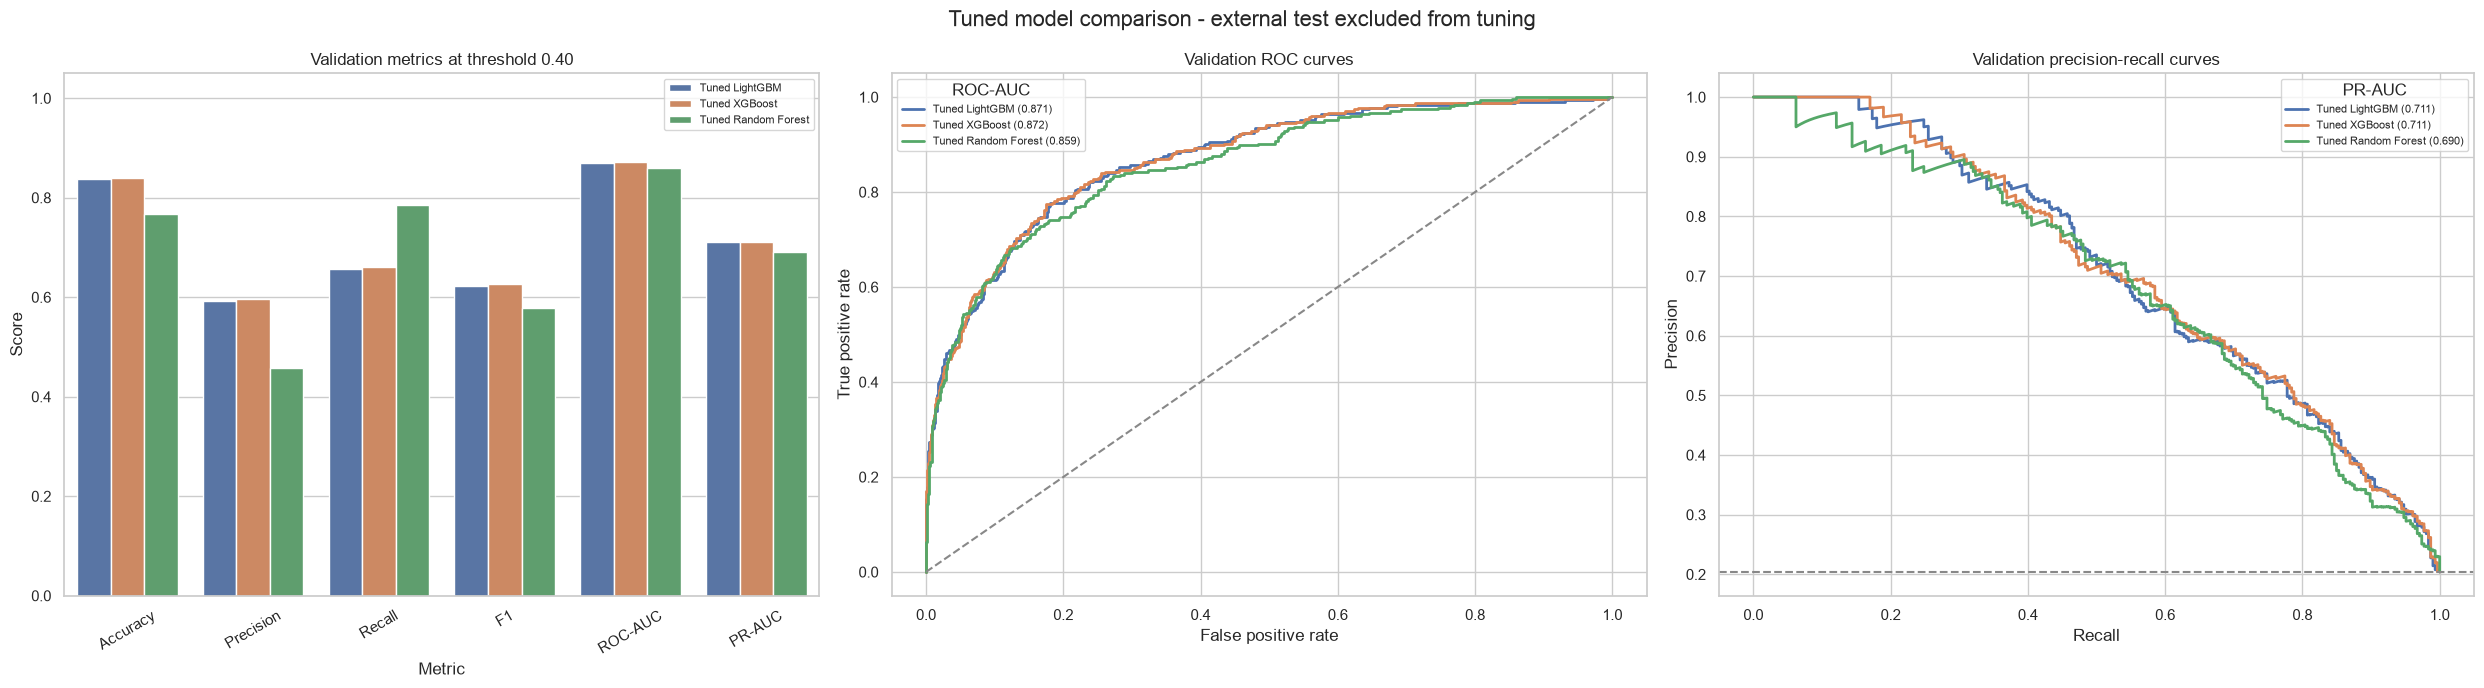

In [10]:
plot_validation_comparison(
    validation_results,
    artifacts,
    data.y_validation,
    config.operating_threshold,
)
plt.show()

# Step 8 — Model selection và threshold report

Các model trong tolerance `0.002` so với CV leader được xem là tương đương; validation F1 tại threshold `0.40` là tie-breaker. External test không tham gia. Plot lựa chọn operating threshold trên validation được lược bỏ; notebook chỉ giữ bảng tham chiếu và threshold đã khóa.


In [11]:
selection = select_tuned_model(
    validation_results,
    artifacts,
    data.y_validation,
    config,
)

print(
    f'CV-equivalent shortlist: {selection.shortlist["Model"].tolist()}'
)
print(f'Selected model: {selection.selected_model_name}')
print(
    'Validation-best F0.5 threshold (reference): '
    f'{selection.validation_f05_threshold:.4f}'
)
print(f'Frozen operating threshold: {selection.operating_threshold:.4f}')
display(selection.threshold_comparison.style.format({
    column: '{:.4f}'
    for column in selection.threshold_comparison.columns
    if column != 'Decision rule'
}))

CV-equivalent shortlist: ['Tuned LightGBM', 'Tuned XGBoost']
Selected model: Tuned XGBoost
Validation-best F0.5 threshold (reference): 0.6680
Frozen operating threshold: 0.4000


,Decision rule,Threshold,Accuracy,Precision,Recall,Specificity,F1,F0.5,Balanced Accuracy,ROC-AUC,PR-AUC
0,Default threshold,0.5000,0.8587,0.6780,0.5850,0.9288,0.6281,0.6571,0.7569,0.8718,0.7114
1,Validation-best F0.5 reference,0.6680,0.8627,0.8049,0.4314,0.9732,0.5617,0.6861,0.7023,0.8718,0.7114
2,Business operating threshold,0.4000,0.8393,0.5959,0.6601,0.8853,0.6264,0.6077,0.7727,0.8718,0.7114


# Step 9 — Final independent test comparison

Từ step này mới dùng `y_test`. Cả ba tuned models và threshold `0.40` đã được đóng băng từ train/validation. Bảng dưới đây được tính hoàn toàn trên `Synthetic-Customer-Churn-Test.csv`; external test không được dùng để tuning hoặc chọn model.


In [12]:
external_results, external_evaluations = evaluate_external_models(
    artifacts,
    data,
    preprocessing,
    threshold=config.operating_threshold,
    tuned_only=True,
)
external = external_evaluations[selection.selected_model_name]

external_table_columns = [
    'Model',
    'Rows',
    'Actual churn',
    'Predicted churn',
    'TN',
    'FP',
    'FN',
    'TP',
    'Threshold',
    'Accuracy',
    'Precision',
    'Recall',
    'Specificity',
    'F1',
    'Balanced Accuracy',
    'ROC-AUC',
    'PR-AUC',
]
display(
    external_results[external_table_columns]
    .style.format({
        'Rows': '{:,}',
        'Actual churn': '{:,}',
        'Predicted churn': '{:,}',
        'TN': '{:,}',
        'FP': '{:,}',
        'FN': '{:,}',
        'TP': '{:,}',
        'Threshold': '{:.2f}',
        'Accuracy': '{:.4f}',
        'Precision': '{:.4f}',
        'Recall': '{:.4f}',
        'Specificity': '{:.4f}',
        'F1': '{:.4f}',
        'Balanced Accuracy': '{:.4f}',
        'ROC-AUC': '{:.4f}',
        'PR-AUC': '{:.4f}',
    })
    .background_gradient(subset=['F1', 'ROC-AUC', 'PR-AUC'], cmap='YlGn')
)
print(f'External source overlap with training source: {data.external_overlap}')


,Model,Rows,Actual churn,Predicted churn,TN,FP,FN,TP,Threshold,Accuracy,Precision,Recall,Specificity,F1,Balanced Accuracy,ROC-AUC,PR-AUC
0,Tuned LightGBM,"1,000",204,210,714,82,76,128,0.40,0.8420,0.6095,0.6275,0.8970,0.6184,0.7622,0.8722,0.6957
1,Tuned XGBoost,"1,000",204,204,716,80,80,124,0.40,0.8400,0.6078,0.6078,0.8995,0.6078,0.7537,0.8680,0.6820
2,Tuned Random Forest,"1,000",204,342,614,182,44,160,0.40,0.7740,0.4678,0.7843,0.7714,0.5861,0.7778,0.8575,0.6802


External source overlap with training source: 0


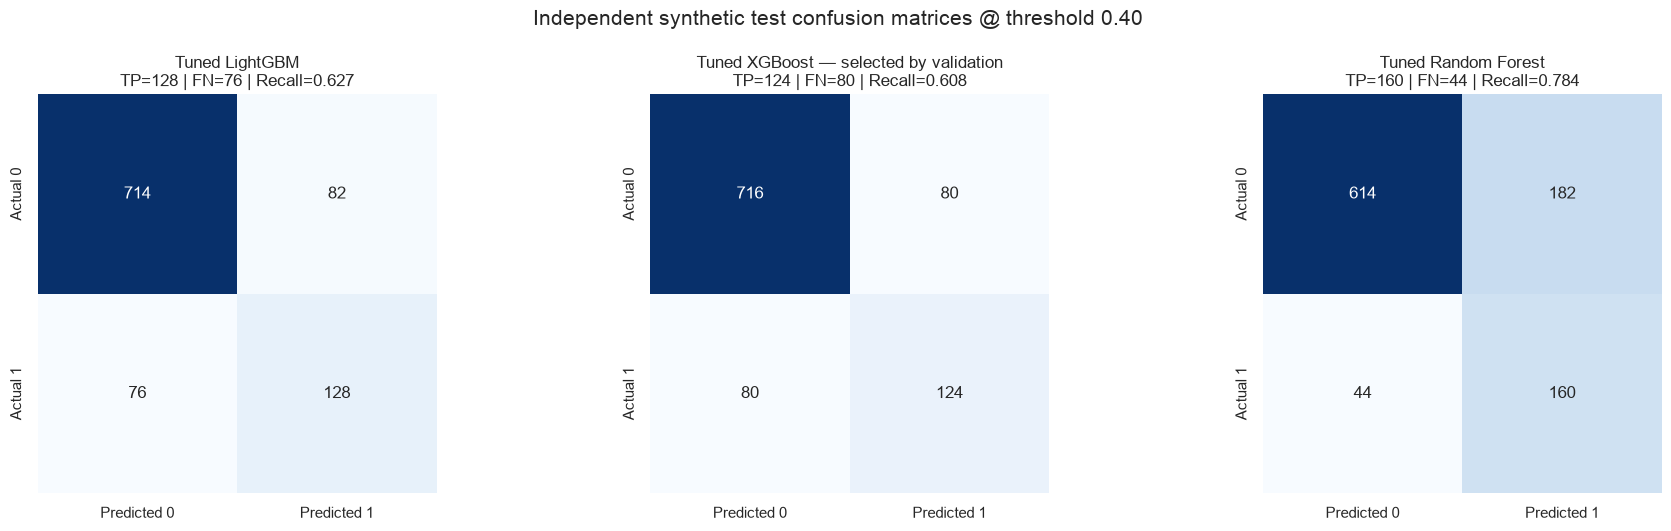

In [13]:
plot_external_confusion_matrices(
    external_evaluations,
    threshold=config.operating_threshold,
    selected_model_name=selection.selected_model_name,
)
plt.show()


# Step 10 — Model recommendation và kết luận

Kết luận dưới đây chỉ sử dụng kết quả từ independent Synthetic test tại threshold `0.40`. Tiêu chí **best overall** ưu tiên F1 để cân bằng Precision–Recall, sau đó dùng PR-AUC và ROC-AUC làm tie-breaker.


In [14]:
test_ranking = external_results.sort_values(
    ['F1', 'PR-AUC', 'ROC-AUC'],
    ascending=False,
).reset_index(drop=True)

best_overall = test_ranking.iloc[0]
recall_leader = external_results.sort_values(
    ['Recall', 'F1'],
    ascending=False,
).iloc[0]
fewest_false_positives = external_results.sort_values(
    ['FP', 'F1'],
    ascending=[True, False],
).iloc[0]

decision_summary = pd.DataFrame([
    {
        'Decision criterion': 'Best overall: F1 → PR-AUC → ROC-AUC',
        'Recommended model': best_overall['Model'],
        'Key result': (
            f"F1={best_overall['F1']:.4f}; "
            f"PR-AUC={best_overall['PR-AUC']:.4f}"
        ),
    },
    {
        'Decision criterion': 'Highest churn recall',
        'Recommended model': recall_leader['Model'],
        'Key result': (
            f"Recall={recall_leader['Recall']:.4f}; "
            f"TP={int(recall_leader['TP'])}; "
            f"FP={int(recall_leader['FP'])}"
        ),
    },
    {
        'Decision criterion': 'Fewest false positives',
        'Recommended model': fewest_false_positives['Model'],
        'Key result': (
            f"FP={int(fewest_false_positives['FP'])}; "
            f"Precision={fewest_false_positives['Precision']:.4f}"
        ),
    },
])
display(decision_summary.style.hide(axis='index'))

display(Markdown(f'''
## Kết luận cuối: chọn **{best_overall['Model']}**

- **{best_overall['Model']}** là lựa chọn tốt nhất nếu cần hiệu quả tổng thể cân bằng: Accuracy **{best_overall['Accuracy']:.4f}**, Precision **{best_overall['Precision']:.4f}**, Recall **{best_overall['Recall']:.4f}**, F1 **{best_overall['F1']:.4f}**, ROC-AUC **{best_overall['ROC-AUC']:.4f}** và PR-AUC **{best_overall['PR-AUC']:.4f}**.
- **{recall_leader['Model']}** chỉ nên ưu tiên khi mục tiêu quan trọng nhất là bắt được nhiều churn: Recall **{recall_leader['Recall']:.4f}**, nhưng có **{int(recall_leader['FP'])} false positives** và Precision chỉ **{recall_leader['Precision']:.4f}**.
- **{fewest_false_positives['Model']}** tạo ít false positives nhất (**{int(fewest_false_positives['FP'])}**) nhưng không vượt **{best_overall['Model']}** về F1, ROC-AUC hoặc PR-AUC.

Vì vậy, với threshold **{config.operating_threshold:.2f}** và mục tiêu cân bằng khả năng phát hiện churn với độ chính xác cảnh báo, model đề xuất cho project là **{best_overall['Model']}**.

> Lưu ý phương pháp: test set đã được xem nhiều lần trong quá trình phân tích, nên đây là khuyến nghị cho project hiện tại. Trước khi production nên đánh giá thêm trên một holdout mới chưa từng được quan sát.
'''))


Decision criterion,Recommended model,Key result
Best overall: F1 → PR-AUC → ROC-AUC,Tuned LightGBM,F1=0.6184; PR-AUC=0.6957
Highest churn recall,Tuned Random Forest,Recall=0.7843; TP=160; FP=182
Fewest false positives,Tuned XGBoost,FP=80; Precision=0.6078



## Kết luận cuối: chọn **Tuned LightGBM**

- **Tuned LightGBM** là lựa chọn tốt nhất nếu cần hiệu quả tổng thể cân bằng: Accuracy **0.8420**, Precision **0.6095**, Recall **0.6275**, F1 **0.6184**, ROC-AUC **0.8722** và PR-AUC **0.6957**.
- **Tuned Random Forest** chỉ nên ưu tiên khi mục tiêu quan trọng nhất là bắt được nhiều churn: Recall **0.7843**, nhưng có **182 false positives** và Precision chỉ **0.4678**.
- **Tuned XGBoost** tạo ít false positives nhất (**80**) nhưng không vượt **Tuned LightGBM** về F1, ROC-AUC hoặc PR-AUC.

Vì vậy, với threshold **0.40** và mục tiêu cân bằng khả năng phát hiện churn với độ chính xác cảnh báo, model đề xuất cho project là **Tuned LightGBM**.

> Lưu ý phương pháp: test set đã được xem nhiều lần trong quá trình phân tích, nên đây là khuyến nghị cho project hiện tại. Trước khi production nên đánh giá thêm trên một holdout mới chưa từng được quan sát.
